# &laquo;Машинное обучение&raquo;, AI Masters

# **Домашняя работа №7**. Методы понижения размерности, кластеризация. Пакеты для интерактивной визуализации.

**ФИО**: Лиза Фоменко

In [ ]:
import numpy as np
import scipy as sp
import pandas as pd

# uncomment if you need it
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'colab'
print("Plotly renderer set to 'colab'")

Plotly renderer set to 'colab'


In [ ]:
!pip install faiss-cpu
!pip install -q umap-learn umap-learn[plot]

In [ ]:
import umap.plot
import faiss

## Задача 1. Подбор параметров UMAP и оценка полученной визуализации (4 балла)

Для вас загружен датасет по данным секвенирования одиночных клеток. Датасет уже предобработан, в задаче нет необходимости вникать в специфику данных (кому интересно - [источник](https://doi.org/10.1101/2021.09.16.460628) датасета).

Ваша задача:
1. (2 балла) Предобработайте ваш датасет: найдите в нем ближайших соседей одним из быстрых способов, поддерживающих sparse-данные. После этого научитесь передавать таких соседей в UMAP (изучите, что принимает на вход параметр `precomputed_knn`). Сравните полученную визуализацию с запуском класса `umap.UMAP` на sparse матрице с исходными данными.

2. (2 балла) Подберите параметры UMAP таким образом, чтобы по данным получались наилучшие кластеры из атрибута `cell_type` (см. метаданные). Придумайте количественный способ оценки получаемого пространства (известная разметка на кластеры в этом пространстве должна быть хорошей). Попробуйте различные параметры UMAP и добейтесь улучшения качества относительно запуска с параметрами по умолчанию.

Бонусные баллы будут ставиться за:
* Хорошую работу, оформление выводов.
* Понятную визуализацию, сравнение, интерактивные графики (если они уместны).
* Учет в получаемой 2D-структуре дополнительной информации из метаданных.
* Все остальные правила из семинара 1 тоже действуют :)

<font color='red'>**Обязательно**</font>: в конце задания продемонстрируйте полученный график / графики и сравните с дефолтными настройками! Если вы делали дополнительную работу, также кратко опишите, что было сделано и продемонстрируйте, что это работает! При проверке мы не сможем проверять ваш код на предмет наличия скрытого (или не очень скрытого) функционала, поэтому **вы не получите доп. баллы, если не покажете, как работает сделанная вами фишка**.

In [ ]:
!wget https://data.bioml.ru/htdocs/courses/bioml/classic_ml/unsupervised/dim_reduction/data/singlecell/expression_data.npz -O expression_data.npz 2> /dev/null
!wget https://data.bioml.ru/htdocs/courses/bioml/classic_ml/unsupervised/dim_reduction/data/singlecell/metadata_row.parquet -O metadata_row.parquet 2> /dev/null
!wget https://data.bioml.ru/htdocs/courses/bioml/classic_ml/unsupervised/dim_reduction/data/singlecell/metadata_col.parquet -O metadata_col.parquet 2> /dev/null

In [ ]:
data = sp.sparse.load_npz('expression_data.npz')
meta_row = pd.read_parquet('metadata_row.parquet')
meta_col = pd.read_parquet('metadata_col.parquet')
data.shape, meta_row.shape, meta_col.shape

((50753, 1000), (50753, 4), (1000, 2))

In [ ]:
meta_row

,donor_id,disease,tissue,cell_type
Fimbria1_AAACGAAGTATCTCGA,donor_1,normal,fimbria of fallopian tube,secretory cell
Fimbria1_AAACGCTGTCAGGTAG,donor_1,normal,fimbria of fallopian tube,secretory cell
Fimbria1_AAAGAACGTGACACAG,donor_1,normal,fimbria of fallopian tube,ciliated epithelial cell
Fimbria1_AAAGAACTCCCGAACG,donor_1,normal,fimbria of fallopian tube,blood vessel endothelial cell
Fimbria1_AAAGAACTCCTTATCA,donor_1,normal,fimbria of fallopian tube,mature NK T cell
...,...,...,...,...
FT4_TTTGTTGCAGCTCATA-1,donor_4,normal,fallopian tube,macrophage
FT4_TTTGTTGGTAGACAGC-1,donor_4,normal,fallopian tube,macrophage
FT4_TTTGTTGGTCAAGCGA-1,donor_4,normal,fallopian tube,myofibroblast cell
FT4_TTTGTTGGTCGCGTCA-1,donor_4,normal,fallopian tube,endothelial cell of lymphatic vessel


In [ ]:
# ну то есть у нас данные об экспрессии клеток из фаллопиевых труб, которые вязли из 4х здоровых женщин (хотя в статье они пишут "4 healthy pre-menopausal subjects")
# по столбцам идут транскрипты из 1000 генов, по строкам - чет непонятно, маркеры какие-то наверное, лень читать было

# у них это +- Figure 1B: Through batch-correction and re-clustering of four healthy donor samples, we defined a stable set of 12 clusters (Figure 1B)

In [ ]:
meta_col

,feature_name,feature_type
ENSG00000000938,FGR,protein_coding
ENSG00000002933,TMEM176A,protein_coding
ENSG00000003436,TFPI,protein_coding
ENSG00000004776,HSPB6,protein_coding
ENSG00000004799,PDK4,protein_coding
...,...,...
ENSG00000283063,TRBV6-2,TR_V_gene
ENSG00000283674,ENSG00000283674,lncRNA
ENSG00000283697,HSFX3,protein_coding
ENSG00000286122,LINC02964,lncRNA


In [ ]:
# инфу из meta_col мне кажется нормально не получится заюзать, тем более что мы понижение размерности делаем, пофиг на нее

In [ ]:
meta_row.cell_type.nunique()    # 12 типов клеток у нас будет

12

### часть 1: сравниваем предпосчитанные kNN с встроенным в UMAP

In [ ]:
# я выбрала IVF из faiss

In [ ]:

X = data.toarray().astype("float32")

d = X.shape[1]
nlist = 100
k = 30

quantizer = faiss.IndexFlatIP(d)

X_faiss = X.copy()
faiss.normalize_L2(X_faiss)
index = faiss.IndexIVFFlat(
    quantizer,
    d,
    nlist,
    faiss.METRIC_INNER_PRODUCT
)
index.train(X_faiss)
index.add(X_faiss)
index.nprobe = 8
similarities, indices = index.search(X_faiss, k)
distances = 1.0 - similarities

In [ ]:
# запускаем UMAP для исходных данных и для обработанных faiss

In [ ]:
X = data.toarray().astype("float32")

mapper = umap.UMAP(
    n_neighbors=k,
    metric="cosine",
    precomputed_knn=(indices, distances),
    random_state=42
).fit(X_faiss)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:2021: UserWarning:

precomputed_knn[2] (knn_search_index) is not an NNDescent object: transforming new data with transform will be unavailable.



In [ ]:
k = 30
X = data.toarray().astype("float32")

mapper_sparce = umap.UMAP(
    n_neighbors=k,
    metric="cosine",
    random_state=42
).fit(X)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [ ]:
# теперь нарисуем графики. я буду юзать интерактивные, хотя мне базовые, которые рисует UMAP, очень нравятся.

# тут плюс интерактивных в том, что мы можем сделать hover_data для каждой точки - ее возьмем из meta_row. Нам нужен донор (batch effect?), часть фаллопиевой трубы, из которой брали клетки, а также подпишем тип клетки для каждой точки

In [ ]:
from bokeh.io import output_notebook
output_notebook()

from bokeh.plotting import figure, show

from bokeh.models import ColumnDataSource
from bokeh.palettes import Category20
from bokeh.models import HoverTool

In [ ]:
# создаем source data для bokeh
source = ColumnDataSource({
    'sparse_x': mapper_sparce.embedding_[:, 0],
    'sparse_y': mapper_sparce.embedding_[:, 1],
    'precomp_x': mapper.embedding_[:, 0],
    'precomp_y': mapper.embedding_[:, 1],
    'cell_type': meta_row.cell_type,
    'tissue': meta_row.tissue,
    'donor_id': meta_row.donor_id
})

tools = ["hover","crosshair","pan","wheel_zoom","zoom_in","zoom_out","box_zoom","undo","redo","reset","tap","save","box_select","poly_select","lasso_select","examine","fullscreen","help"]

# задаем цветовую палитру, нужна контрастная и поддерживающая 12 levels of factors
from bokeh.transform import factor_cmap
color_map = factor_cmap(
    field_name="cell_type",
    palette=Category20[20],
    factors=meta_row.cell_type.unique().astype(str)
)


# fig1 будут sparse данные, обработанные UMAP
fig_1 = figure(tools=tools, width=1000, height=1000, title="UMAP on sparse data")
fig_1.scatter(
    x='sparse_x',
    y='sparse_y',
    fill_color=color_map,
    source=source,
    alpha = 0.7,
    line_color=None,
    size=7,
)
fig_1.title.align = "center"
fig_1.title.text_font_size = "24pt"

# fig1 будут данные, предобработнные с помощью faiss
fig_2 = figure(tools=tools, width=1300, height=1000, title="UMAP with precomputed kNN")
fig_2.scatter(
    x="precomp_x",
    y="precomp_y",
    fill_color=color_map,
    source=source,
    alpha=0.7,
    legend_group="cell_type",
    line_color=None,
    size=7,
)
fig_2.title.align = "center"
fig_2.title.text_font_size = "24pt"

# так как цвета одинаковы, легенду нарисуем справа от всего графика
fig_2.legend.orientation = "vertical"
fig_2.add_layout(fig_2.legend[0], "right")


# и добавим hover data, которую описала выше
hover = HoverTool(
    tooltips=[
    ("cell_type", "@cell_type"),
    ("tissue", "@tissue"),
    ("donor_id", "@donor_id")]
)
fig_1.add_tools(hover)
fig_2.add_tools(hover)


# и нарисуем на одном графике
from bokeh.layouts import gridplot
grid = gridplot([[fig_1,  fig_2]])

show(grid)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# вот такие графики у меня получились. В целом, мы видим, что кластеры получились одинаковые (просто расположение разное) как с использованием предпосчитанных kNN, так и без них посредством внутренней обработки UMAP.


# касаемо "интерактивности" самого графика - мне очень не нравится, что при наведении на точки показываются данные для всех точек, которые попали под поле курсора, а не ближайшая точка (как, например, в plotly.express - но он медленный оказался)

# на графике мы видим как читсые кластеры, например киллерные T-клетки (желтый кластер), клетки реснитчатого эпителия (бледно-голубой кластер), B-клетки, мастоциты.
# но есть и проблемы. Например, кластер секреторных клеток не целостный (темно-синий) - на каждом из рисунков он разделен на несколько довольно обособленных классов, + какая-то часть находится совсем близко к эндотелию сосудов.
# Аналогично пострадали эндотелиальные клетки лимфатических сосудов (красный кластер), от которого отделился небольной кусок.
# При этом мы видим контаминацию в кластере макрофагов (светло-зеленый кластер) и в перицитах.

# ну и в целом мне не нравится, что у нас есть очень мелкие "куски" кластеров, которые раскиданы по полю.

# Бросается в глаза также зелено-розрвый кластер, но у самих авторов наблюдается такая же проблема, хотя она полностью объяснима: у нас есть фибробласты, миофибробласты и гладкомышечные клетки. Очевидно, что они будут
# кластеризоваться близко друг к другу, и в идеале фибробласты и миоциты будут разделены миофибробластами.

In [ ]:
# Придумайте количественный способ оценки получаемого пространства (известная разметка на кластеры в этом пространстве должна быть хорошей)

# ну можно воспользоваться просто коэффициентом силуэта и calinski_harabasz_score.

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score

In [ ]:
print(f'sparse data: silhouette_score = {silhouette_score(mapper_sparce.embedding_, meta_row.cell_type):.4f}, calinski_harabasz_score = {calinski_harabasz_score(mapper_sparce.embedding_, meta_row.cell_type):.2f}')
print(f'precomp kNN: silhouette_score = {silhouette_score(mapper.embedding_, meta_row.cell_type):.4f}, calinski_harabasz_score = {calinski_harabasz_score(mapper.embedding_, meta_row.cell_type):.2f}')

sparse data: silhouette_score = 0.5892, calinski_harabasz_score = 62234.31
precomp kNN: silhouette_score = 0.6121, calinski_harabasz_score = 57487.89


In [ ]:
# мы видим, что значения коэффициентов получились одинаковые примерно - мы именно это и наблюдаем на гарфиках (одинаковые кластеры разного расположения), но по umap на sparse данных даже получше получилось (на самом деле видно что
# там где был faiss больше раздолбанных на куски кластеров получилось)
# поэтому снова считать faiss снова не будем, просто запускаем umap с разными параметрами и ищем наилучшее разделение

# задача топ1: избавиться от мелких кластеров - постараемся их объединить

### часть 2: подбираем параметры UMAP для лучшего разделения кластеров

In [ ]:
# а есть ли у нас батч эффект?

<Axes: >

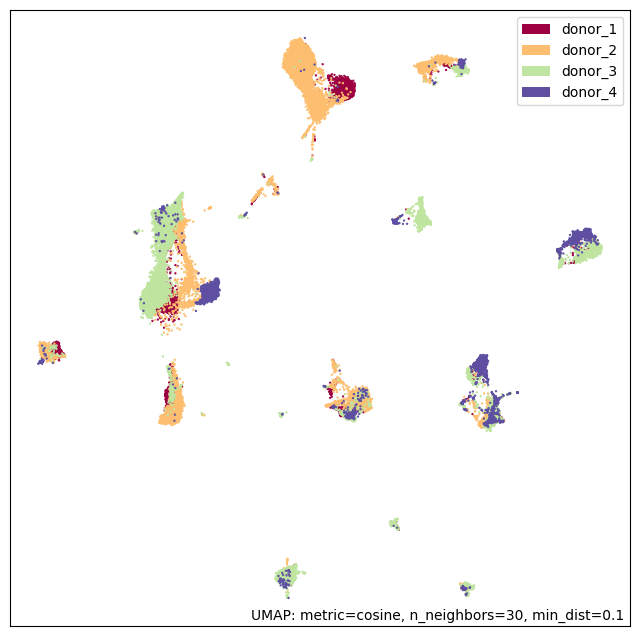

In [ ]:
umap.plot.points(mapper_sparce, labels = meta_row.donor_id)

In [ ]:
# ура, у нас есть батч эффект) наиболее сильно его можно увмдеть на секреторных клетках, которые разбиваются на два кластера: donor_1 и donor_2 (кластер сверху слева) и donor_3 + donor_4 (треугольных кластер справа под легендой)
# на остальных кластерах это не так замето, но все же лучше это убрать)

In [ ]:
!pip install inmoose

In [ ]:
from inmoose.pycombat import pycombat_norm

batch = meta_row["donor_id"].astype(str).tolist()

X_batch_corrected = pycombat_norm(X.T, batch=batch)

In [ ]:
mapper_batch_corrected = umap.UMAP(
    n_neighbors=k,
    metric="cosine",
    random_state=42
).fit(np.array(X_batch_corrected).T)


n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.




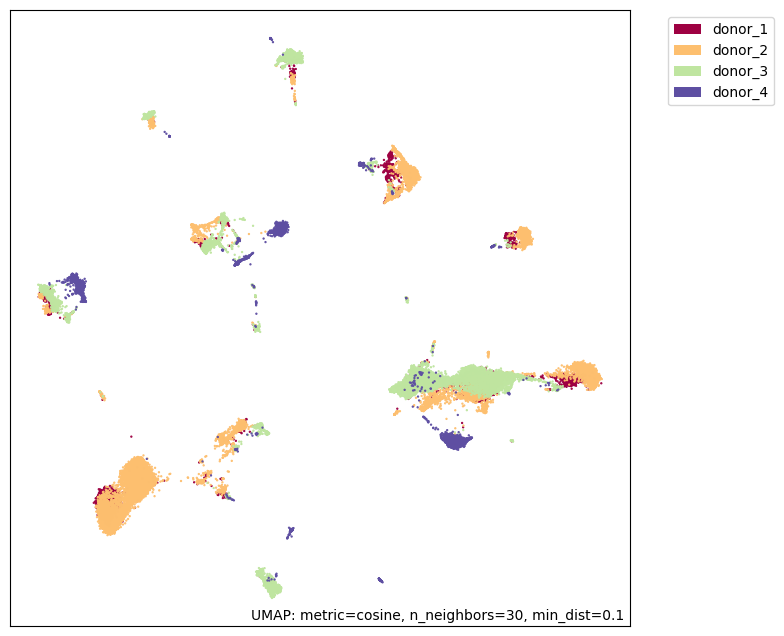

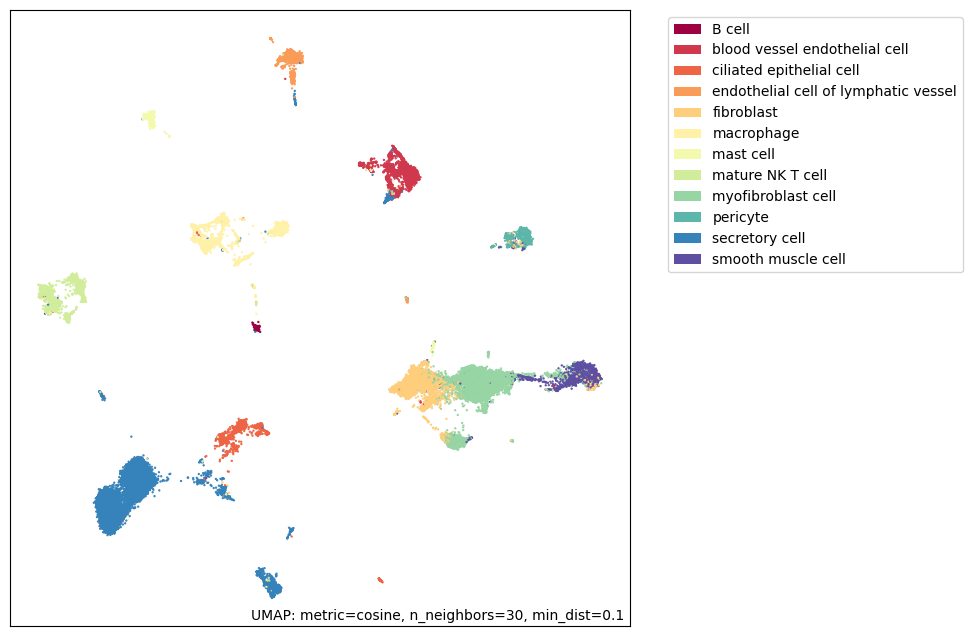

In [ ]:
ax = umap.plot.points(mapper_batch_corrected, labels = meta_row.donor_id)

legend = ax.get_legend()
legend.set_bbox_to_anchor((1.05, 1))
legend.set_loc('upper left')
plt.show()

ax = umap.plot.points(mapper_batch_corrected, labels = meta_row.cell_type)
legend = ax.get_legend()
legend.set_bbox_to_anchor((1.05, 1))
legend.set_loc('upper left')
plt.show()

In [ ]:
# пупупу) не сильно помогло, к сожалению, видимо batc correction уже была проведена. Но я на всякий случай буду использовать именно X с дополительной batch correction

# по графику окраски по батчам (=донорам) мы как будто бы видим, что секреторные клетки все еще разнесены на разные подкластеры, но все-таки я буду надеяться, что это помогло(
# и, меняя параметры UMAP, мы можем добиться лучшей кластеризации! тем более у авторов этот кластер тоже такой "лапистый", кмк просто клетки довольно неоднородные

# кстати вот интересно, что часть секреторных клеток стабильно относится к эндотелию сосудов( Но у авторов наблюдается примерно такая же картина, так что это может быть окей

# вообще конечно помешало еще и то, что у нас уже обработанные данные, а не raw(

In [ ]:
k = 600
dist = 0.1

mapper_metrics = umap.UMAP(
    n_neighbors=k,
    metric="cosine",
    random_state=42,
    min_dist=dist
).fit(np.array(X_batch_corrected).T)


n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.




In [ ]:
print(f'sparse data: silhouette_score = {silhouette_score(mapper_sparce.embedding_, meta_row.cell_type):.4f}, calinski_harabasz_score = {calinski_harabasz_score(mapper_sparce.embedding_, meta_row.cell_type):.2f}')
print(f'precomp kNN: silhouette_score = {silhouette_score(mapper.embedding_, meta_row.cell_type):.4f}, calinski_harabasz_score = {calinski_harabasz_score(mapper.embedding_, meta_row.cell_type):.2f}')
print(f'best metrics: silhouette_score = {silhouette_score(mapper_metrics.embedding_, meta_row.cell_type):.4f}, calinski_harabasz_score = {calinski_harabasz_score(mapper_metrics.embedding_, meta_row.cell_type):.2f}')

sparse data: silhouette_score = 0.5892, calinski_harabasz_score = 62234.31
precomp kNN: silhouette_score = 0.6121, calinski_harabasz_score = 57487.89
best metrics: silhouette_score = 0.6274, calinski_harabasz_score = 87435.05


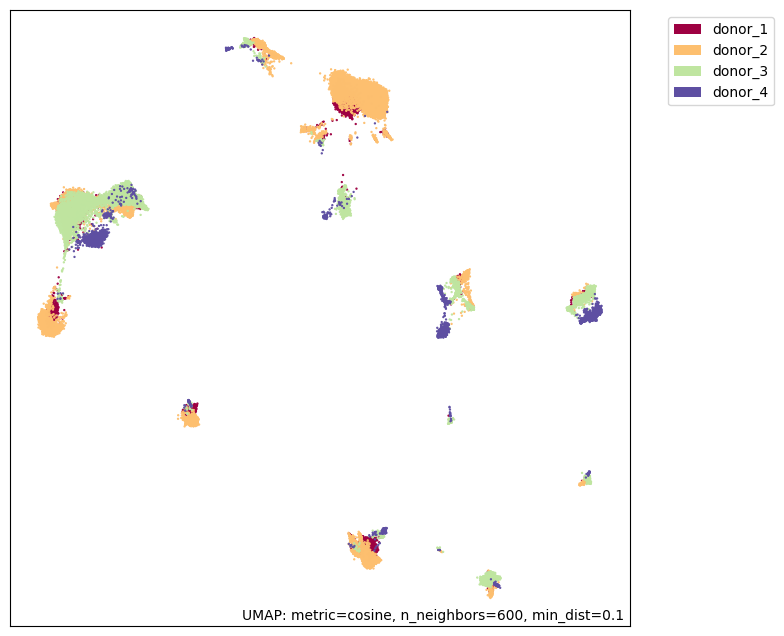

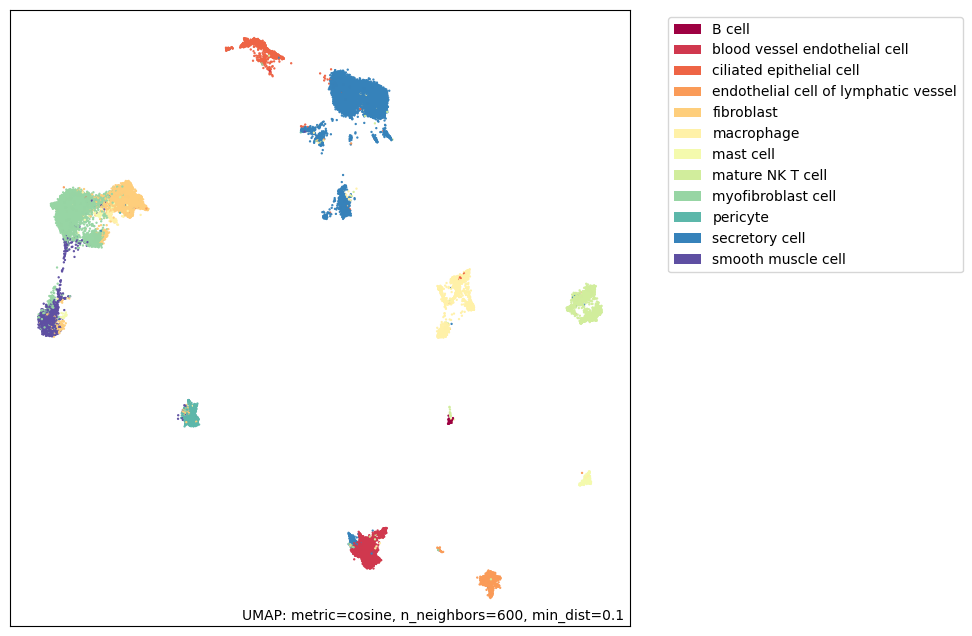

In [ ]:
ax = umap.plot.points(mapper_metrics, labels = meta_row.donor_id)

legend = ax.get_legend()
legend.set_bbox_to_anchor((1.05, 1))
legend.set_loc('upper left')
plt.show()

ax = umap.plot.points(mapper_metrics, labels = meta_row.cell_type)
legend = ax.get_legend()
legend.set_bbox_to_anchor((1.05, 1))
legend.set_loc('upper left')
plt.show()

In [ ]:
# метрики улучшились - успех. но все-таки на рисунке кластеры остаются не совсем такими, как их хочется видеть. увеличение dist приводит к потере качества метрик, но я все равно нарисую графики, так как визуально выглядит красивее/понятнее

In [ ]:
k = 50
dist = 0.3

mapper_best = umap.UMAP(
    n_neighbors=k,
    metric="cosine",
    random_state=42,
    min_dist=dist
).fit(np.array(X_batch_corrected).T)


n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.




In [ ]:
print(f'sparse data: silhouette_score = {silhouette_score(mapper_sparce.embedding_, meta_row.cell_type):.4f}, calinski_harabasz_score = {calinski_harabasz_score(mapper_sparce.embedding_, meta_row.cell_type):.2f}')
print(f'precomp kNN: silhouette_score = {silhouette_score(mapper.embedding_, meta_row.cell_type):.4f}, calinski_harabasz_score = {calinski_harabasz_score(mapper.embedding_, meta_row.cell_type):.2f}')
print(f'best metrics: silhouette_score = {silhouette_score(mapper_metrics.embedding_, meta_row.cell_type):.4f}, calinski_harabasz_score = {calinski_harabasz_score(mapper_metrics.embedding_, meta_row.cell_type):.2f}')
print(f'best picture: silhouette_score = {silhouette_score(mapper_best.embedding_, meta_row.cell_type):.4f}, calinski_harabasz_score = {calinski_harabasz_score(mapper_best.embedding_, meta_row.cell_type):.2f}')

sparse data: silhouette_score = 0.5892, calinski_harabasz_score = 62234.31
precomp kNN: silhouette_score = 0.6121, calinski_harabasz_score = 57487.89
best metrics: silhouette_score = 0.6274, calinski_harabasz_score = 87435.05
best picture: silhouette_score = 0.5259, calinski_harabasz_score = 68202.27


In [ ]:
# просто оставлю этот график как игру с dist) пусть будут метрики похуже, зато кластеры более разляпистые, why not, тем более визуально мне он довольно симпатичен

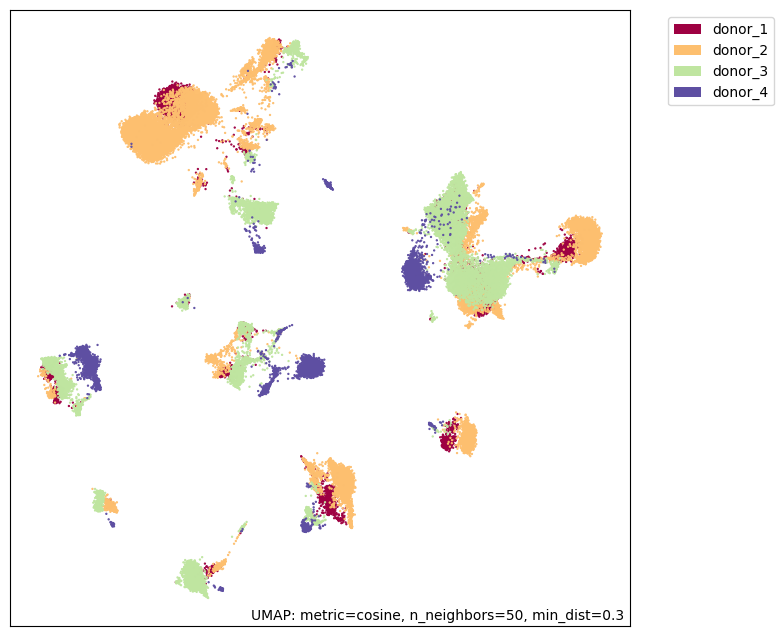

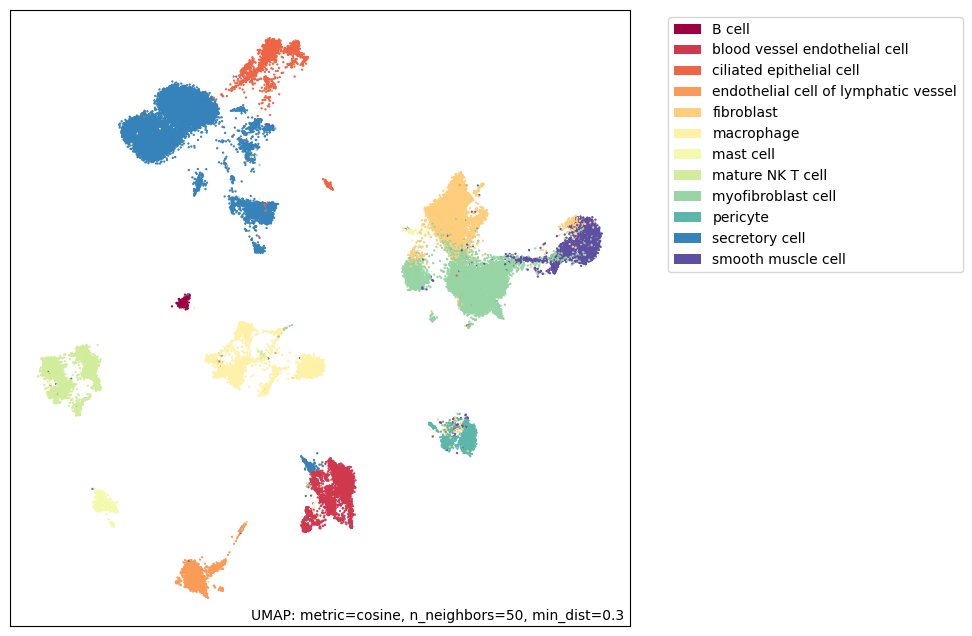

In [ ]:
# убедимся, что батч-эффекта точно нет, и кластеры получились хорошие

ax = umap.plot.points(mapper_best, labels = meta_row.donor_id)

legend = ax.get_legend()
legend.set_bbox_to_anchor((1.05, 1))
legend.set_loc('upper left')
plt.show()

ax = umap.plot.points(mapper_best, labels = meta_row.cell_type)
legend = ax.get_legend()
legend.set_bbox_to_anchor((1.05, 1))
legend.set_loc('upper left')
plt.show()

In [ ]:
# создаем source data для bokeh
source = ColumnDataSource({
    'sparse_x': mapper_sparce.embedding_[:, 0],
    'sparse_y': mapper_sparce.embedding_[:, 1],
    'precomp_x': mapper.embedding_[:, 0],
    'precomp_y': mapper.embedding_[:, 1],
    'best_x': mapper_best.embedding_[:, 0],
    'best_y': mapper_best.embedding_[:, 1],
    'best_metrics_x': mapper_metrics.embedding_[:, 0],
    'best_metrics_y': mapper_metrics.embedding_[:, 1],
    'cell_type': meta_row.cell_type,
    'tissue': meta_row.tissue,
    'donor_id': meta_row.donor_id
})

tools = ["hover","pan","wheel_zoom","zoom_in","zoom_out","box_zoom","undo","redo","reset","tap","save","box_select","poly_select","lasso_select","examine","fullscreen","help"]

# задаем цветовую палитру, нужна контрастная и поддерживающая 12 levels of factors
from bokeh.transform import factor_cmap
color_map = factor_cmap(
    field_name="cell_type",
    palette=Category20[20],
    factors=meta_row.cell_type.unique().astype(str)
)


# fig1 будут sparse данные, обработанные UMAP
fig_1 = figure(tools=tools, width=800, height=800, title="UMAP on sparse data")
fig_1.scatter(
    x='sparse_x',
    y='sparse_y',
    fill_color=color_map,
    source=source,
    alpha = 0.7,
    line_color=None,
    size=7,
)
fig_1.title.align = "center"
fig_1.title.text_font_size = "24pt"

# fig1 будут данные, предобработнные с помощью faiss
fig_2 = figure(tools=tools, width=800, height=800, title="UMAP with precomputed kNN")
fig_2.scatter(
    x="precomp_x",
    y="precomp_y",
    fill_color=color_map,
    source=source,
    alpha=0.7,
    line_color=None,
    size=7,
)
fig_2.title.align = "center"
fig_2.title.text_font_size = "24pt"


fig_3 = figure(tools=tools, width=800, height=800, title="UMAP with best plot")
fig_3.scatter(
    x="best_x",
    y="best_y",
    fill_color=color_map,
    source=source,
    alpha=0.7,
    line_color=None,
    size=7,
)
fig_3.title.align = "center"
fig_3.title.text_font_size = "24pt"


fig_4 = figure(tools=tools, width=1100, height=800, title="UMAP with best metrics")
fig_4.scatter(
    x="best_metrics_x",
    y="best_metrics_y",
    fill_color=color_map,
    source=source,
    alpha=0.7,
    legend_group="cell_type",
    line_color=None,
    size=7,
)
fig_4.title.align = "center"
fig_4.title.text_font_size = "24pt"

# так как цвета одинаковы, легенду нарисуем справа от всего графика
fig_4.legend.orientation = "vertical"
fig_4.add_layout(fig_4.legend[0], "right")


# и добавим hover data, которую описала выше
hover = HoverTool(
    tooltips=[
    ("cell_type", "@cell_type"),
    ("tissue", "@tissue"),
    ("donor_id", "@donor_id")]
)
fig_1.add_tools(hover)
fig_2.add_tools(hover)
fig_3.add_tools(hover)
fig_4.add_tools(hover)


# и нарисуем на одном графике
from bokeh.layouts import gridplot
grid = gridplot([[fig_1,  fig_2, fig_3, fig_4]])

show(grid)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# и вывод: графики на raw data, с использованием faiss, просто график, который мне почему-то нравится чуть больше остальных (хотя по метрикам он уступает лучшему), и график с лучшими метриками

In [ ]:
del X, data, meta_col, quantizer, index, similarities, indices, distances, mapper, mapper_sparce, mapper_batch_corrected, grid, batch

## Задача 2. **Tool**: оценка стабильности кластеров, получаемых выбранным методом DR (6 баллов)

Напишите класс `DimRedValidator`, которая будет производить оценку стабильности кластеров, получаемых с помощью метода снижения размерности (выберите один или несколько из рассмотренных на семинаре: t-SNE, UMAP, PaCMAP, LocalMAP).

При инициализации класс должен принимать на вход:
* Класс или функцию для обучения эмбеддинга (т.к. разные фреймворки не обязательно следуют интерфейсу fit-predict Scikit-learn, сделайте возможность гибко запускать вашу функцию с эмбеддингами разных методов DR)
* Класс или функцию для обучения кластеризатора
* Параметры для эмбеддинга, кластеризатора и прочего

Какие методы **должен** поддерживать ваш класс:
* `fit` - обучает ваш класс и несколько эмбеддингов с заданными параметрами
    * Как бонус - можете сделать так, чтобы класс мог принимать уже готовые эмбеддинги для дальнейшего сравнения - это полезно, если сравниваете разные методы или уже готовые кластеризации
* `draw_embeddings` - совместно отрисовывает несколько панелей интерактивных графиков с эмбеддингами
* `draw_clusterized` - то же самое, но с раскраской по кластерам, полученным по _первому_ эмбеддингу
* `draw_colored` - то же самое, но с раскраской по координатам, взятым по _первому_ эмбеддингу ([источник](https://docs.bokeh.org/en/latest/docs/examples/basic/scatters/color_scatter.html) для вдохновения, как раскрашивать)

Что еще _может_ поддерживать ваш класс (за дополнительные хорошие и рабочие идеи тоже будут бонусы!):
* Отрисовка интерактивных диагностических графиков (подобных [таким](https://umap-learn.readthedocs.io/en/latest/plotting.html#diagnostic-plotting))
* Оценка сходства кластеризаций над разными эмбеддингами (например, [индексом Рэнда](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.rand_score.html)), отрисовка двух наименее похожих результатов DimRed
* Поиск субкластеров и проверка их стабильности ([пример](https://hdbscan.readthedocs.io/en/latest/how_to_detect_branches.html) для вдохновения)

<font color='red'>**Обязательно**</font>: в конце задания продемонстрируйте работу вашего класса **для всех обязательных и сделанных вами дополнительных заданий**! Без демонстрации получите 0 баллов за задание, независимо от объема выполненной работы. Проверьте, что ваши графики отображаются в Colab; если не
отображаются или вы не уверены, то вставьте их скриншоты под ними.

In [ ]:
!pip install -q pacmap

In [ ]:
from sklearn.manifold import TSNE
from pacmap import PaCMAP, LocalMAP
import itertools as it
from bokeh.layouts import gridplot
from bokeh.transform import factor_cmap
from matplotlib.colors import to_hex
import sklearn


In [ ]:
class DimRedValidator:
    def __init__(self, dimred_class, embed_kwargs, cluster_class, cluster_kwargs, random_states):
        """
        A class for Dimension Reduction classes comparison: computing, visualizing, and comparing multiple dimensionality reduction embeddings and their clustering stability

        Parameters
        ----------
        dimred_class : str or list of str
            Dimensionality reduction method(s) to be used for comparison.
            Supported values: {'t-SNE', 'UMAP', 'PaCMAP', 'LocalMAP'}.
            If a single string is provided, it is reused for all random states.

        embed_kwargs : list of dicts or dict
            Kwargs, provided as dict, for every dimension reduction class in dimred_class.
            If a single dict is provided, it will be used in all runs repeatedly.

        cluster_class : class
            Class from sklearn.cluster or another class that supports .fit() method and has attribute .labels_ with clusters prediction per object.

        cluster_kwargs : dict
            Kwargs, provided as dict, for cluster_class.

        random_states : list of int
            Random seeds used for dimensionality reduction runs.
            The number of random states determines the number of embeddings computed.


        Attributes
        ----------
        dimred_class : list of str
            Dimensionality reduction method(s) to be used for comparison.

        embed_kwargs : list of dicts
            Kwargs for every dimension reduction class in dimred_class.

        cluster_class : class
            Class for clustering.

        cluster_kwargs : dict
            Kwargs for cluster_class.

        random_states : list of int
            Random seeds used for dimensionality reduction runs.

        embeddings : list of np.array
            Embeddings from each of the dimred_class.



        Methods
        -------
        fit(data, input_embed = None):
            Computes dimensionality reduction embeddings for the input data.
            All external embeddings, provided via input_embed, will also be used in analysis.

         draw_embeddings(metadata = None, color_by = None, hover = None):
            Creates an interactive plot for every embedding. Provided hover tooltips, which will be shown for the plot, must be present in the metadata.
            The plot will be colored via color_by column from metadata.

        draw_clusterized(metadata = None, hover = None)
            Applies the clustering algorithm cluster_class(**cluster_kwargs) to the first embedding.
            Creates an interactive plot for every embedding. Provided hover tooltips, which will be shown for the plot, must be present in the metadata.
            The plot will be colored via cluster predictions got for the first embedding.

        draw_colored(metadata = None, hover = None)
            Creates an interactive plot for every embedding. Provided hover tooltips, which will be shown for the plot, must be present in the metadata.
            The plot will be colored via coords of the first embedding.

        cluster_stability(draw_worst = True, metadata = None, hover = None)
            Computes pairwise Rand indices between clusterings obtained from different embeddings and optionally visualizes the least stable pair.


        Notes
        -----
        Total number of computed embeddings is determined by the number of given seeds. Assert the number of given dimension reduction classes given in dimred_class agrees with the number of provided seeds.

        """

        if isinstance(dimred_class, str):
            assert dimred_class in ['t-SNE', 'UMAP', 'PaCMAP', 'LocalMAP']
            self.dimred_class = [dimred_class] * len(random_states)
        else:
            assert len(random_states) == len(dimred_class), f'number of dimred_classes must be the same as number of random_states for them'
            for dimclass in dimred_class:
                assert dimclass in ['t-SNE', 'UMAP', 'PaCMAP', 'LocalMAP']
            self.dimred_class = dimred_class

        if isinstance(embed_kwargs, dict):
            self.embed_kwargs = [embed_kwargs] * len(random_states)
        else:
            assert len(embed_kwargs) == len(random_states)
            self.embed_kwargs = embed_kwargs

        self.cluster_class = cluster_class
        self.cluster_kwargs = cluster_kwargs
        self.random_states = random_states

        self.embeddings = []


    def fit(self, data, input_embed = None):
        '''
        data - np.array for which embeddings are to be computed
        input_embed - list of np.arrays external embeddings for data
        '''

        dimred_registry = {
                "UMAP": lambda randm_state, kwargs: umap.UMAP(random_state=randm_state, **kwargs),
                "t-SNE": lambda randm_state, kwargs: TSNE(random_state=randm_state, **kwargs),
                "PaCMAP": lambda randm_state, kwargs: PaCMAP(random_state=randm_state, **kwargs),
                "LocalMAP": lambda randm_state, kwargs: LocalMAP(random_state=randm_state, **kwargs),
        }

        for i, dimred_class in enumerate(self.dimred_class):
            print(f'fit {dimred_class} dim_red class')
            embed = dimred_registry[dimred_class](self.random_states[i], self.embed_kwargs[i]).fit_transform(data)
            self.embeddings.append(embed)

        if input_embed is not None:
            for inp_emb in input_embed:
                self.embeddings.append(inp_emb)


    def draw_embeddings(self, metadata = None, color_by = None, hover = None):
        '''
        metadata: df
        color_by: str, key from metadata, used to color the dots on the plot
        hover: list bokeh-styled hover values [ ("name1", "@name1"), ("name2", "@name2")...], all used names are to be in metadata
        '''
        data_source = {}
        tools = ["hover","pan","wheel_zoom","zoom_in","zoom_out","box_zoom","undo","redo","reset","tap","save","box_select","poly_select","lasso_select","examine","fullscreen","help"]

        for i, embed in enumerate(self.embeddings):
            data_source[f'x_{i}'] = embed[:, 0]
            data_source[f'y_{i}'] = embed[:, 1]

        if metadata is not None:
            for col in metadata.columns:
                data_source[col] = metadata[col]

        source = ColumnDataSource(data_source)

        if color_by:
            assert color_by in metadata.keys()
            color_map = factor_cmap(
                field_name=color_by,
                palette=Category20[20],
                factors=metadata[color_by].unique().astype(str))
        else:
            color_map = 'blue'

        if hover:
            for pair in hover:
                assert pair[0] in metadata.keys()

            hover = HoverTool(
                tooltips = hover
            )

        figures = []

        for i in range(len(self.embeddings) - 1):
            if i <= len(self.random_states) - 1:
                title = f'{self.dimred_class[i]}, random_state = {self.random_states[i]}'
            else:
                title = f'input embedding number {i - (len(self.random_states) - 1)}'
            fig = figure(tools=tools, width=800, height=800, title=title)
            fig.scatter(
                x=f'x_{i}',
                y=f'y_{i}',
                fill_color=color_map,
                source=source,
                alpha = 0.7,
                line_color=None,
                size=7
            )
            fig.title.align = "center"
            fig.title.text_font_size = "24pt"
            fig.add_tools(hover)

            figures.append(fig)


        if color_by:
            if i <= len(self.random_states) - 1:
                title = f'{self.dimred_class[i+1]}, random_state = {self.random_states[i+1]}'
            else:
                title = f'input embedding number {i + 1 - (len(self.random_states) - 1)}'
            fig = figure(tools=tools, width=1100, height=800, title=title)
            fig.scatter(
                x=f'x_{i+1}',
                y=f'y_{i+1}',
                fill_color=color_map,
                source=source,
                alpha = 0.7,
                line_color=None,
                size=7,
                legend_group=color_by,
            )
            fig.title.align = "center"
            fig.title.text_font_size = "24pt"
            if hover:
                fig.add_tools(hover)
            fig.legend.orientation = "vertical"
            fig.add_layout(fig.legend[0], "right")

            figures.append(fig)

        else:
            if i <= len(self.random_states) - 1:
                title = f'{self.dimred_class[i]}, random_state = {self.random_states[i]}'
            else:
                title = f'input embedding number {i - (len(self.random_states) - 1)}'
            fig = figure(tools=tools, width=800, height=800, title=title)
            fig.scatter(
                x=f'x_{i+1}',
                y=f'y_{i+1}',
                fill_color=color_map,
                source=source,
                alpha = 0.7,
                line_color=None,
                size=7
            )
            fig.title.align = "center"
            fig.title.text_font_size = "24pt"

            if hover:
                fig.add_tools(hover)

            figures.append(fig)

        grid = gridplot([figures])
        show(grid)


    def draw_clusterized(self, metadata = None, hover = None):
        '''
        metadata: df
        hover: list bokeh-styled hover values [ ("name1", "@name1"), ("name2", "@name2")...], all used names are to be in metadata
        '''
        cluster_labels =  self.cluster_class(**self.cluster_kwargs).fit(self.embeddings[0]).labels_
        tools = ["hover","pan","wheel_zoom","zoom_in","zoom_out","box_zoom","undo","redo","reset","tap","save","box_select","poly_select","lasso_select","examine","fullscreen","help"]

        data_source = {}
        color_by = 'color'
        data_source['cluster_labels'] = cluster_labels.astype(str)

        for i, embed in enumerate(self.embeddings):
            data_source[f'x_{i}'] = embed[:, 0]
            data_source[f'y_{i}'] = embed[:, 1]

        if metadata is not None:
            for col in metadata.columns:
                data_source[col] = metadata[col]

        source = ColumnDataSource(data_source)

        color_map = factor_cmap(
            field_name='cluster_labels',
            palette=Category20[20],
            factors=np.unique(cluster_labels).astype(str))


        if hover:
            for pair in hover:
                assert pair[0] in metadata.keys()

            hover = HoverTool(
                tooltips = hover
            )

        figures = []

        for i in range(len(self.embeddings)):
            if i <= len(self.random_states) - 1:
                title = f'{self.dimred_class[i]}, random_state = {self.random_states[i]}'
            else:
                title = f'input embedding number {i - (len(self.random_states) - 1)}'
            fig = figure(tools=tools, width=800, height=800, title=title)
            fig.scatter(
                x=f'x_{i}',
                y=f'y_{i}',
                fill_color=color_map,
                source=source,
                alpha = 0.7,
                line_color=None,
                size=7
            )
            fig.title.align = "center"
            fig.title.text_font_size = "24pt"

            if hover:
                fig.add_tools(hover)

            figures.append(fig)

        grid = gridplot([figures])
        show(grid)


    def draw_colored(self, metadata = None, hover = None):
        '''
        metadata: df
        hover: list bokeh-styled hover values [ ("name1", "@name1"), ("name2", "@name2")...], all used names are to be in metadata
        '''
        tools = ["hover","pan","wheel_zoom","zoom_in","zoom_out","box_zoom","undo","redo","reset","tap","save","box_select","poly_select","lasso_select","examine","fullscreen","help"]
        data_source = {}

        x_color = self.embeddings[0][:, 0]
        x_color = (x_color - min(x_color.min(), 0))
        x_color = x_color / (x_color.max())

        y_color = self.embeddings[0][:, 1]
        y_color = (y_color - min(y_color.min(), 0))
        y_color = y_color / (y_color.max())

        colors = [to_hex((r**0.5, g**0.5, 0.2)) for r, g in zip(x_color, y_color)]
        data_source["color"] = colors

        for i, embed in enumerate(self.embeddings):
            data_source[f'x_{i}'] = embed[:, 0]
            data_source[f'y_{i}'] = embed[:, 1]

        if metadata is not None:
            for col in metadata.columns:
                data_source[col] = metadata[col]

        source = ColumnDataSource(data_source)

        if hover:
            for pair in hover:
                assert pair[0] in metadata.keys()

            hover = HoverTool(
                tooltips = hover
            )

        figures = []

        for i in range(len(self.embeddings)):
            if i <= len(self.random_states) - 1:
                title = f'{self.dimred_class[i]}, random_state = {self.random_states[i]}'
            else:
                title = f'input embedding number {i - (len(self.random_states) - 1)}'
            fig = figure(tools=tools, width=800, height=800, title=title)
            fig.scatter(
                x=f'x_{i}',
                y=f'y_{i}',
                fill_color='color',
                source=source,
                alpha = 0.7,
                line_color=None,
                size=7
            )
            fig.title.align = "center"
            fig.title.text_font_size = "24pt"

            if hover:
                fig.add_tools(hover)

            figures.append(fig)

        grid = gridplot([figures])
        show(grid)


    def cluster_stability(self, draw_worst = True, metadata = None, hover = None):
        '''
        draw_worst: bool
        metadata: df
        hover: list bokeh-styled hover values [ ("name1", "@name1"), ("name2", "@name2")...], all used names are to be in metadata
        '''
        clustering_results = []
        all_scores = 0
        min_score = float('inf')
        for i in range(len(self.embeddings)):
            cluster_labels =  self.cluster_class(**self.cluster_kwargs).fit(self.embeddings[i]).labels_
            clustering_results.append(cluster_labels)

        for pair in it.combinations(range(len(self.embeddings)), r=2):
            score = sklearn.metrics.rand_score(clustering_results[pair[0]], clustering_results[pair[1]])
            if score < min_score:
                to_draw = [pair[0], pair[1], score]
                min_score = score
            print(f'Rand score for embedding {pair[0]} and embedding {pair[1]} is {score:.4f}')
            all_scores += score
        print(f'Mean Rand score is {all_scores / (len(self.embeddings) * (len(self.embeddings) - 1) / 2):.4f}')

        if draw_worst:
            # создаем source data для bokeh
            source = ColumnDataSource({
                'x_1': self.embeddings[to_draw[0]][:, 0],
                'y_1': self.embeddings[to_draw[0]][:, 1],
                'x_2': self.embeddings[to_draw[1]][:, 0],
                'y_2': self.embeddings[to_draw[1]][:, 1],
                'labels1': clustering_results[to_draw[0]],
                'labels2': clustering_results[to_draw[1]]})

            tools = ["hover","pan","wheel_zoom","zoom_in","zoom_out","box_zoom","undo","redo","reset","tap","save","box_select","poly_select","lasso_select","examine","fullscreen","help"]

            color_map1 = factor_cmap(
                field_name="labels1",
                palette=Category20[20],
                factors=np.unique(clustering_results[to_draw[0]]).astype(str)
            )

            color_map2 = factor_cmap(
                field_name="labels2",
                palette=Category20[20],
                factors=np.unique(clustering_results[to_draw[1]]).astype(str)
            )


            if to_draw[0] <= len(self.random_states) - 1:
                title1 = f'{self.dimred_class[to_draw[0]]}, random_state = {self.random_states[to_draw[0]]}'
            else:
                title1 = f'input embedding number {to_draw[0] - (len(self.random_states) - 1)}'

            if to_draw[1] <= len(self.random_states) - 1:
                title2 = f'{self.dimred_class[to_draw[1]]}, random_state = {self.random_states[to_draw[1]]}'
            else:
                title2 = f'input embedding number {to_draw[1] - (len(self.random_states) - 1)}'

            fig_1 = figure(tools=tools, width=800, height=800, title=title1)
            fig_1.scatter(
                x='x_1',
                y='y_1',
                fill_color=color_map1,
                source=source,
                alpha = 0.7,
                line_color=None,
                size=7,
            )
            fig_1.title.align = "center"
            fig_1.title.text_font_size = "24pt"

            fig_2 = figure(tools=tools, width=800, height=800, title=title2)
            fig_2.scatter(
                x="x_2",
                y="y_2",
                fill_color=color_map2,
                source=source,
                alpha=0.7,
                line_color=None,
                size=7,
            )
            fig_2.title.align = "center"
            fig_2.title.text_font_size = "24pt"

            if hover:
                hover = HoverTool(tooltips=hover)
                fig_1.add_tools(hover)
                fig_2.add_tools(hover)

            grid = gridplot([[fig_1,  fig_2]])
            show(grid)

In [ ]:
from sklearn.cluster import KMeans

dimred_class = ['t-SNE', 'UMAP', 'PaCMAP', 'LocalMAP']


# параметры от балды поставила
tsne_dict = {
    "n_components": 2,
    "perplexity": 30,
    "init": "pca",
    "learning_rate": "auto",
    "verbose": 0,
}
umap_dict = {
    "n_components": 2,
    "n_neighbors": 50,
    "min_dist": 0.2,
    "metric": "cosine",
}
pacmp_dict = {
    "n_components": 2,
    "n_neighbors": 50,
    "MN_ratio": 0.3,
    "FP_ratio": 3.0,
    "verbose": False
}

localmap_dict = {
    "n_components": 2,
    "n_neighbors": 50
}


embed_kwargs = [tsne_dict,umap_dict, pacmp_dict, localmap_dict]


cluster_class = KMeans
cluster_kwargs = {"n_clusters": 12, "init": 'k-means++', "random_state": 777}
random_states = [13, 57, 69, 571]

In [ ]:
metadata = meta_row
color_by = 'cell_type'
hover = [("cell_type", "@cell_type"), ("tissue", "@tissue"), ("donor_id", "@donor_id")]

In [ ]:
validator = DimRedValidator(dimred_class, embed_kwargs, cluster_class, cluster_kwargs, random_states)

In [ ]:
input_embed = [mapper_best.embedding_, mapper_metrics.embedding_]

In [78]:
validator.fit(np.array(X_batch_corrected).T, input_embed)

fit t-SNE dim_red class
fit UMAP dim_red class



n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.




fit PaCMAP dim_red class


fit LocalMAP dim_red class


In [79]:
validator.draw_embeddings(metadata, color_by, hover)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# по-моему t-SNE неплохо сработал, хотя был от балды запущен, если бы чуток поварьировать параметры, вообще пушечно бы поолучилось) жаль, работает медленно. возможно, поэтому и был супер popular для секов
# PaCMAP и LocalMAP, конечно, нужно настраивать, получилась пока что шляпа какая-то

In [80]:
validator.draw_clusterized(metadata, hover)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# тут, получается, по t-SNE окраска, не то чтобы фантастично кластеризовалось) кластер секреторных клеток разделился, но с ними в прицнипе траблы были всегда

In [81]:
validator.draw_colored(metadata, hover)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# немного психоделическая раскраска, ну да ладно

In [82]:
validator.cluster_stability(draw_worst = True, metadata = metadata, hover = hover)

Rand score for embedding 0 and embedding 1 is 0.9574
Rand score for embedding 0 and embedding 2 is 0.9273
Rand score for embedding 0 and embedding 3 is 0.9139
Rand score for embedding 0 and embedding 4 is 0.9413
Rand score for embedding 0 and embedding 5 is 0.9426
Rand score for embedding 1 and embedding 2 is 0.9348
Rand score for embedding 1 and embedding 3 is 0.8965
Rand score for embedding 1 and embedding 4 is 0.9741
Rand score for embedding 1 and embedding 5 is 0.9780
Rand score for embedding 2 and embedding 3 is 0.8982
Rand score for embedding 2 and embedding 4 is 0.9283
Rand score for embedding 2 and embedding 5 is 0.9315
Rand score for embedding 3 and embedding 4 is 0.9013
Rand score for embedding 3 and embedding 5 is 0.9005
Rand score for embedding 4 and embedding 5 is 0.9856
Mean Rand score is 0.9341


In [ ]:
# 'Similarity score between 0.0 and 1.0, inclusive, 1.0 stands for perfect match' - для большинства кластеров у нас получается 0.95+, а более низкие значения для 3го эмбеддинга - это как раз LocalMAP, в котором сами эмбеддинги крайне неудачные